## IMDB dataset

In [1]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
 num_words=10000)

17464789/17464789 [==============================] - 11s 1us/step


In [3]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
train_labels[0]

1

In [5]:
max([max(sequence) for sequence in train_data])


9999

In [6]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
 [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
 [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

1641221/1641221 [==============================] - 1s 0us/step


In [10]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [11]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


In [15]:
model.compile(optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [16]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]


In [17]:
history = model.fit(partial_x_train,
 partial_y_train,
 epochs=20,
 batch_size=512,
 validation_data=(x_val, y_val))

Epoch 1/20
30/30 [==============================] - 2s 37ms/step - loss: 0.5403 - accuracy: 0.7653 - val_loss: 0.4188 - val_accuracy: 0.8423
Epoch 2/20
30/30 [==============================] - 1s 21ms/step - loss: 0.3305 - accuracy: 0.8968 - val_loss: 0.3267 - val_accuracy: 0.8809
Epoch 3/20
30/30 [==============================] - 0s 15ms/step - loss: 0.2435 - accuracy: 0.9253 - val_loss: 0.2850 - val_accuracy: 0.8923
Epoch 4/20
30/30 [==============================] - 1s 20ms/step - loss: 0.1916 - accuracy: 0.9418 - val_loss: 0.2742 - val_accuracy: 0.8917
Epoch 5/20
30/30 [==============================] - 0s 16ms/step - loss: 0.1552 - accuracy: 0.9519 - val_loss: 0.2870 - val_accuracy: 0.8856
Epoch 6/20
30/30 [==============================] - 0s 15ms/step - loss: 0.1290 - accuracy: 0.9609 - val_loss: 0.2970 - val_accuracy: 0.8822
Epoch 7/20
30/30 [==============================] - 1s 18ms/step - loss: 0.1068 - accuracy: 0.9693 - val_loss: 0.2957 - val_accuracy: 0.8853
Epoch 8/20
30

In [18]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

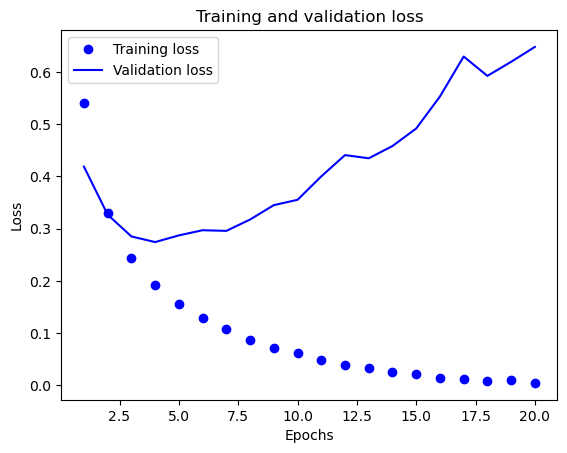

In [19]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

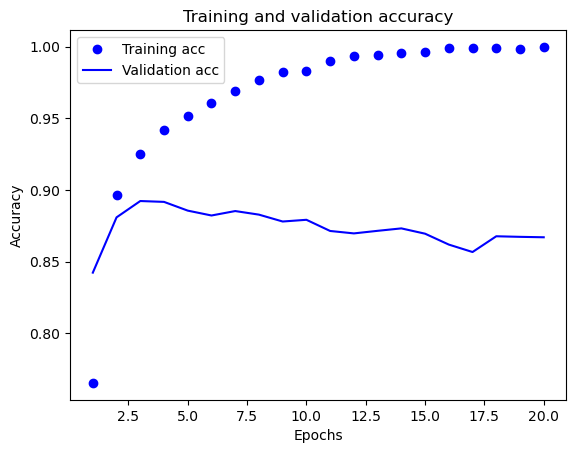

In [20]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [22]:
model = keras.Sequential([
 layers.Dense(16, activation="relu"),
 layers.Dense(16, activation="relu"),
 layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
 loss="binary_crossentropy",
 metrics=["accuracy"])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
results

Epoch 1/4
49/49 [==============================] - 1s 9ms/step - loss: 0.4570 - accuracy: 0.8242
Epoch 2/4
49/49 [==============================] - 0s 8ms/step - loss: 0.2608 - accuracy: 0.9080
Epoch 3/4
49/49 [==============================] - 1s 10ms/step - loss: 0.2023 - accuracy: 0.9284
Epoch 4/4
782/782 [==============================] - 2s 2ms/step - loss: 0.3310 - accuracy: 0.8698


[0.3310476541519165, 0.8697599768638611]

In [24]:
model.predict(x_test)

782/782 [==============================] - 2s 2ms/step


array([[0.15603042],
       [0.9986306 ],
       [0.35611328],
       ...,
       [0.0757436 ],
       [0.04634382],
       [0.41660988]], dtype=float32)

## Reuters dataset

In [27]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
 num_words=10000)
print(len(train_data))
print(len(test_data))

8982
2246


In [28]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [29]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
 [(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
 [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

550378/550378 [==============================] - 0s 0us/step


In [30]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [31]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

In [33]:
model = keras.Sequential([
 layers.Dense(64, activation="relu"),
 layers.Dense(64, activation="relu"),
 layers.Dense(46, activation="softmax")
])

In [34]:
model.compile(optimizer="rmsprop",
 loss="categorical_crossentropy",
 metrics=["accuracy"])

In [35]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

history = model.fit(partial_x_train,
partial_y_train,
epochs=20,
batch_size=512,
validation_data=(x_val, y_val))

Epoch 1/20
16/16 [==============================] - 2s 43ms/step - loss: 2.5556 - accuracy: 0.5297 - val_loss: 1.6786 - val_accuracy: 0.6390
Epoch 2/20
16/16 [==============================] - 0s 29ms/step - loss: 1.3555 - accuracy: 0.7149 - val_loss: 1.2717 - val_accuracy: 0.7240
Epoch 3/20
16/16 [==============================] - 0s 29ms/step - loss: 1.0103 - accuracy: 0.7818 - val_loss: 1.1179 - val_accuracy: 0.7530
Epoch 4/20
16/16 [==============================] - 0s 25ms/step - loss: 0.8002 - accuracy: 0.8269 - val_loss: 1.0170 - val_accuracy: 0.7760
Epoch 5/20
16/16 [==============================] - 0s 23ms/step - loss: 0.6404 - accuracy: 0.8632 - val_loss: 0.9480 - val_accuracy: 0.7960
Epoch 6/20
16/16 [==============================] - 0s 27ms/step - loss: 0.5144 - accuracy: 0.8909 - val_loss: 0.9228 - val_accuracy: 0.8040
Epoch 7/20
16/16 [==============================] - 0s 25ms/step - loss: 0.4152 - accuracy: 0.9136 - val_loss: 0.9380 - val_accuracy: 0.7900
Epoch 8/20
16

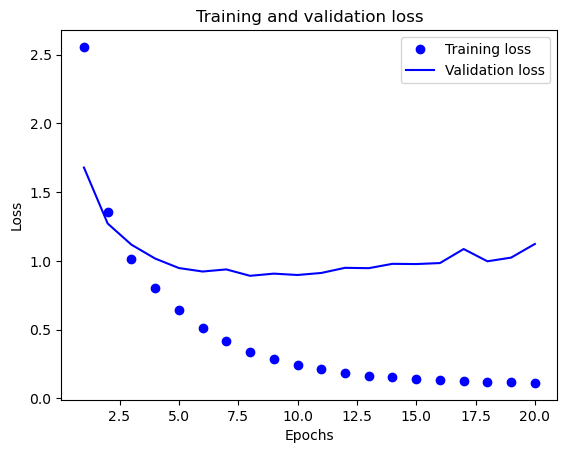

In [36]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

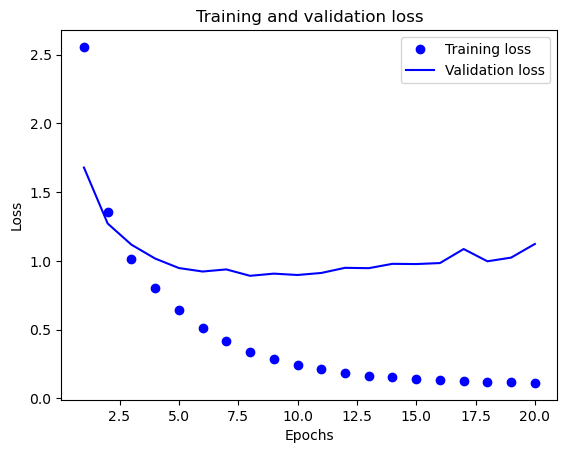

In [37]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"), 
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"])
model.fit(x_train,
    y_train,
    epochs=9,
    batch_size=512)
results = model.evaluate(x_test, y_test)
results

Epoch 1/9
18/18 [==============================] - 1s 20ms/step - loss: 2.5744 - accuracy: 0.4709
Epoch 2/9
18/18 [==============================] - 0s 27ms/step - loss: 1.3602 - accuracy: 0.7145
Epoch 3/9
18/18 [==============================] - 0s 19ms/step - loss: 0.9893 - accuracy: 0.7895
Epoch 4/9
18/18 [==============================] - 0s 20ms/step - loss: 0.7701 - accuracy: 0.8366
Epoch 5/9
18/18 [==============================] - 0s 19ms/step - loss: 0.6066 - accuracy: 0.8753
Epoch 6/9
18/18 [==============================] - 0s 19ms/step - loss: 0.4804 - accuracy: 0.9017
Epoch 7/9
18/18 [==============================] - 0s 19ms/step - loss: 0.3840 - accuracy: 0.9187
Epoch 8/9
18/18 [==============================] - 0s 19ms/step - loss: 0.3180 - accuracy: 0.9323
Epoch 9/9
71/71 [==============================] - 0s 3ms/step - loss: 0.9555 - accuracy: 0.7970


[0.9554985761642456, 0.796972393989563]

In [40]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels) == np.array(test_labels_copy)
hits_array.mean()


0.19011576135351738

In [43]:
predictions = model.predict(x_test)

71/71 [==============================] - 0s 2ms/step


In [44]:
predictions[0].shape

(46,)

In [45]:
np.sum(predictions[0])

0.99999976

In [46]:
np.argmax(predictions[0])

3

In [47]:
model.compile(optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [48]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"])
model.fit(partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val))

Epoch 1/20
63/63 [==============================] - 2s 21ms/step - loss: 2.6648 - accuracy: 0.4597 - val_loss: 1.8947 - val_accuracy: 0.5660
Epoch 2/20
63/63 [==============================] - 1s 16ms/step - loss: 1.6680 - accuracy: 0.5862 - val_loss: 1.5401 - val_accuracy: 0.5920
Epoch 3/20
63/63 [==============================] - 1s 14ms/step - loss: 1.3575 - accuracy: 0.6428 - val_loss: 1.3777 - val_accuracy: 0.6640
Epoch 4/20
63/63 [==============================] - 1s 15ms/step - loss: 1.1733 - accuracy: 0.6981 - val_loss: 1.3074 - val_accuracy: 0.6760
Epoch 5/20
63/63 [==============================] - 1s 13ms/step - loss: 1.0489 - accuracy: 0.7228 - val_loss: 1.2611 - val_accuracy: 0.7000
Epoch 6/20
63/63 [==============================] - 1s 22ms/step - loss: 0.9507 - accuracy: 0.7542 - val_loss: 1.2417 - val_accuracy: 0.7210
Epoch 7/20
63/63 [==============================] - 2s 25ms/step - loss: 0.8665 - accuracy: 0.7825 - val_loss: 1.2561 - val_accuracy: 0.7210
Epoch 8/20
63

##  Boston housing dataset

In [49]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = (
 boston_housing.load_data())

57026/57026 [==============================] - 0s 1us/step


In [52]:
print(train_data.shape)
print(test_data.shape)
print(train_targets)

(404, 13)
(102, 13)
[15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4 12.1 17.9 23.1 19.9
 15.7  8.8 50.  22.5 24.1 27.5 10.9 30.8 32.9 24.  18.5 13.3 22.9 34.7
 16.6 17.5 22.3 16.1 14.9 23.1 34.9 25.  13.9 13.1 20.4 20.  15.2 24.7
 22.2 16.7 12.7 15.6 18.4 21.  30.1 15.1 18.7  9.6 31.5 24.8 19.1 22.
 14.5 11.  32.  29.4 20.3 24.4 14.6 19.5 14.1 14.3 15.6 10.5  6.3 19.3
 19.3 13.4 36.4 17.8 13.5 16.5  8.3 14.3 16.  13.4 28.6 43.5 20.2 22.
 23.  20.7 12.5 48.5 14.6 13.4 23.7 50.  21.7 39.8 38.7 22.2 34.9 22.5
 31.1 28.7 46.  41.7 21.  26.6 15.  24.4 13.3 21.2 11.7 21.7 19.4 50.
 22.8 19.7 24.7 36.2 14.2 18.9 18.3 20.6 24.6 18.2  8.7 44.  10.4 13.2
 21.2 37.  30.7 22.9 20.  19.3 31.7 32.  23.1 18.8 10.9 50.  19.6  5.
 14.4 19.8 13.8 19.6 23.9 24.5 25.  19.9 17.2 24.6 13.5 26.6 21.4 11.9
 22.6 19.6  8.5 23.7 23.1 22.4 20.5 23.6 18.4 35.2 23.1 27.9 20.6 23.7
 28.  13.6 27.1 23.6 20.6 18.2 21.7 17.1  8.4 25.3 13.8 22.2 18.4 20.7
 31.6 30.5 20.3  8.8 19.2 19.4 23.1 23.  14.8 48.8 22.6 33.4 

In [54]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

In [55]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
 ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

In [57]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)


Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [58]:
all_scores

[1.833154320716858, 2.5321996212005615, 2.4240384101867676, 2.1992640495300293]

In [60]:
np.mean(all_scores)

2.247164100408554

In [61]:
num_epochs = 500
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)


Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [62]:
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

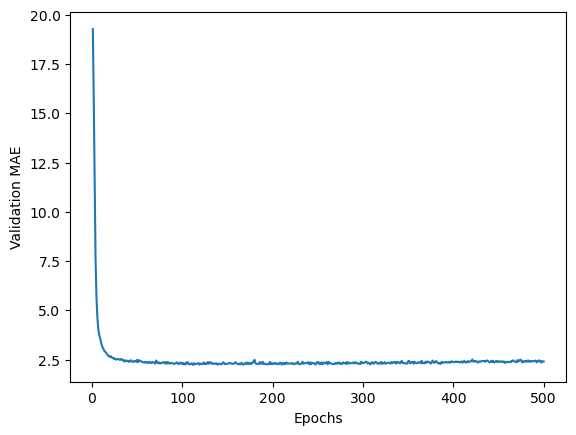

In [63]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [64]:
model = build_model()
model.fit(train_data, train_targets,epochs=130, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 [==============================] - 0s 1ms/step - loss: 657.5264 - mae: 25.1035


In [65]:
test_mae_score

25.10353660583496

In [66]:
predictions = model.predict(test_data)
predictions[0]

4/4 [==============================] - 0s 1ms/step


array([28.140076], dtype=float32)